## Introduction

In this notebook, you'll learn how to use PyTorch's tools to create and optimize neural network models. PyTorch provides the `nn` module for building models and the `optim` module for handling the optimization automatically. You'll also learn how the choice of learning rate and optimizer affects whether and how quickly your model learns.

#### TODO: Improve Intro

## Setup

### Import Libraries

In [1]:
import copy

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import torchinfo

### Utility Functions

In [2]:

def do_linear_regression_interactive(model, X, y_obs, optimizer, nepochs=30):
    """Interactive training for linear regression"""


    # store initial model state to reset before training
    initial_state = copy.deepcopy(model.state_dict())

    def train_and_plot(epoch_to_show):
        # reset model to initial state
        model.load_state_dict(copy.deepcopy(initial_state))

        losses = []
        # train up to the selected epoch
        for epoch in range(epoch_to_show + 1):
            optimizer.zero_grad()
            y_pred = model(X)
            loss = (y_pred - y_obs).square().mean()
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        # plot the data and model at this step
        with torch.no_grad():
            y_pred = model(X)
            loss = (y_pred - y_obs).square().mean()

        fig, axes = plt.subplots(ncols = 2, figsize = (10, 5))
        axes[0].set_title(f"Data and Model\nEpoch={epoch_to_show}, loss={loss:.4f}")
        axes[0].plot(X, y_obs, "o", color="black")
        axes[0].plot(X, model.weight.item()*X, color="r", label="Model")
        axes[0].set_xlabel('X')
        axes[0].set_ylabel('y')
        axes[0].legend()

        axes[1].set_title(f'Loss Throughout Training')
        axes[1].plot(np.arange(epoch_to_show+1), losses)
        axes[1].set_ylabel('Loss')
        axes[1].set_xlabel('Epoch Nr.')

    # create slider with steps of 1
    epoch_slider = widgets.IntSlider(min=0, max=nepochs, step=1, value=0, description='Epoch:')
    widgets.interact(train_and_plot, epoch_to_show=epoch_slider)

def do_multifeature_regression_interactive(model, X, y_obs, optimizer, nepochs=2000):
    """Interactive training for multi-feature regression with different feature scales."""

    # store initial model and optimizer state to reset before training
    initial_model_state = copy.deepcopy(model.state_dict())
    initial_optimizer_state = copy.deepcopy(optimizer.state_dict())

    def train_and_plot(epoch_to_show):
        # reset model and optimizer to initial state
        model.load_state_dict(copy.deepcopy(initial_model_state))
        optimizer.load_state_dict(copy.deepcopy(initial_optimizer_state))

        losses = []
        # train up to the selected epoch
        for epoch in range(epoch_to_show + 1):
            optimizer.zero_grad()
            y_pred = model(X)
            loss = (y_pred - y_obs).square().mean()
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        # compute final loss
        with torch.no_grad():
            y_pred = model(X)
            loss = (y_pred - y_obs).square().mean()

        fig, axes = plt.subplots(ncols=3, figsize=(10, 5))

        axes[0].set_title(f"Data and Model\nEpoch={epoch_to_show}, loss={loss:.4f}")
        axes[0].plot(X[:, 0], y_obs, "o", color="black")
        axes[0].plot(X[:, 0], model.weight[0][0].item()*X[:, 0] - model.bias.item(), color="r", label="Model")
        axes[0].set_xlabel('X (first feature)')
        axes[0].set_ylabel('y')
        axes[0].legend()

        axes[1].set_title(f"Data and Model\nEpoch={epoch_to_show}, loss={loss:.4f}")
        axes[1].plot(X[:, 1], y_obs, "o", color="black")
        axes[1].plot(X[:, 1], model.weight[0][1].item()*X[:, 1] - model.bias.item(), color="r", label="Model")
        axes[1].set_xlabel('X (second feature)')
        axes[1].set_ylabel('y')
        axes[1].legend()

        # loss over epochs
        axes[2].set_title('Loss Throughout Training')
        axes[2].plot(np.arange(epoch_to_show + 1), losses)
        axes[2].set_ylabel('Loss')
        axes[2].set_xlabel('Epoch Nr.')

        plt.tight_layout()

    # create slider
    epoch_slider = widgets.IntSlider(min=0, max=nepochs, step=50, value=0, description='Epoch:')
    widgets.interact(train_and_plot, epoch_to_show=epoch_slider)


class utils:
    do_linear_regression_interactive = do_linear_regression_interactive
    do_multifeature_regression_interactive = do_multifeature_regression_interactive

## Section 1: How to Build a Neural Network Model

A neural network model consists of layers that transform input data into output predictions. The simplest layer is a linear layer, which multiplies inputs by weights and adds a bias - exactly what you did manually in the previous session. PyTorch's `nn.Linear` creates these layers for you, and `nn.Sequential` lets you stack multiple layers together to build deeper networks.

| Code | Description |
| :-- | :-- |
| `nn.Linear(n_features_in, n_features_out)` | Creates a linear model that takes in `n_features_in` input features (nodes) and outputs `n_features_out` features (nodes).|
| `nn.Sequential(`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(1,10),`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(10,1)`<br>`)` | Creates a container where multiple layers are stacked in a sequential order. This ensures that input is passed through the network in that order during the forward pass.|
| `model = nn.Sequential(`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(2,20),`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(20,10),`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(10,1)`<br>`)` | Assigns a the container to a variable `model`. This model has 2 input nodes, two hidden layers with 20 and 10 nodes, respectively, and one output node. |

**Example**: Create the model illustrated below, which has 3 input features and 2 output features:

```mermaid
flowchart LR
  %% Layers
  subgraph IN["Input Layer"]
    direction TB
    i1(( ))
    i2(( ))
    i3(( ))
  end

  subgraph OUT["Output Layer"]
    direction TB
    o1(( ))
    o2(( ))
  end

  %% Dense connections: Input -> Hidden
  i1 --> o1
  i2 --> o1
  i3 --> o1

  i1 --> o2
  i2 --> o2
  i3 --> o2

  %% Styling
  classDef input fill:#F4A261,stroke:#333,stroke-width:1px;
  classDef hidden fill:#2ECC71,stroke:#333,stroke-width:1px;
  classDef output fill:#4D7CFE,stroke:#333,stroke-width:1px;

  class i1,i2,i3 input;
  class o1,o2 output;

```

In [3]:
model = nn.Linear(3, 2)
model

Linear(in_features=3, out_features=2, bias=True)

Make sure data passes successfully through the model, and the output has the right shape:

In [4]:
data = torch.randn(100, 3)
model(data).shape

torch.Size([100, 2])

How many total parameters need to be trained in this model? (`torchinfo.summary(model)`):

In [5]:
torchinfo.summary(model)

Layer (type:depth-idx)                   Param #
Linear                                   8
Total params: 8
Trainable params: 8
Non-trainable params: 0

**Exercise**: Create the model illustrated below, which has 4 input features and 1 output features:

```mermaid
flowchart LR
  %% Layers
  subgraph IN["Input Layer"]
    direction TB
    i1(( ))
    i2(( ))
    i3(( ))
    i4(( ))
  end

  subgraph OUT["Output Layer"]
    direction TB
    o1(( ))
  end

  %% Dense connections: Input -> Hidden
  i1 --> o1
  i2 --> o1
  i3 --> o1
  i4 --> o1

  %% Styling
  classDef input fill:#F4A261,stroke:#333,stroke-width:1px;
  classDef hidden fill:#2ECC71,stroke:#333,stroke-width:1px;
  classDef output fill:#4D7CFE,stroke:#333,stroke-width:1px;

  class i1,i2,i3,i4 input;
  class o1 output;

```


In [6]:
model = nn.Linear(4,1)
model

Linear(in_features=4, out_features=1, bias=True)

Make sure data passes successfully through the model, and the output has the right shape:

In [7]:
data = torch.randn(100, 4)
model(data).shape

torch.Size([100, 1])

How many total parameters need to be trained in this model? (`torchinfo.summary(model)`):

In [8]:
torchinfo.summary(model)

Layer (type:depth-idx)                   Param #
Linear                                   5
Total params: 5
Trainable params: 5
Non-trainable params: 0

 **Exercise**: Create the model illustrated below, which has 3 input features, 2 hidden features and 1 output feature (Note: Use `nn.Sequential()`):

```mermaid
flowchart LR
  %% Layers
  subgraph IN["Input Layer"]
    direction TB
    i1(( ))
    i2(( ))
    i3(( ))
  end

  subgraph HID["Hidden Layer"]
    direction TB
    h1(( ))
    h2(( ))
  end

  subgraph OUT["Output Layer"]
    direction TB
    o1(( ))
    o2(( ))
  end

  %% Dense connections: Input -> Hidden
  i1 --> h1
  i2 --> h1
  i3 --> h1
  
  i1 --> h2
  i2 --> h2
  i3 --> h2

  h1 --> o1
  h2 --> o1

  h1 --> o2
  h2 --> o2
  

  %% Styling
  classDef input fill:#F4A261,stroke:#333,stroke-width:1px;
  classDef hidden fill:#2ECC71,stroke:#333,stroke-width:1px;
  classDef output fill:#4D7CFE,stroke:#333,stroke-width:1px;

  class i1,i2,i3 input;
  class h1,h2 hidden;
  class o1,o2 output;

```


In [9]:
model = nn.Sequential(nn.Linear(3, 2), nn.Linear(2, 2))
model

Sequential(
  (0): Linear(in_features=3, out_features=2, bias=True)
  (1): Linear(in_features=2, out_features=2, bias=True)
)

Make sure data passes successfully through the model, and the output has the right shape:

In [10]:
data = torch.randn(100, 3)
model(data).shape

torch.Size([100, 2])

How many total parameters need to be trained in this model? (`torchinfo.summary(model)`):

In [11]:
torchinfo.summary(model)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Linear: 1-1                            8
├─Linear: 1-2                            6
Total params: 14
Trainable params: 14
Non-trainable params: 0

 **Exercise**: As the number of nodes increases, the style of visualization changes to more of a summary.  Create the model illustrated below, which has 8 input features, 20 hidden features and 1 output feature (Note: Use `nn.Sequential()`):

```mermaid
flowchart LR
  x["Input\n(batch, 8)"]
  l1["Linear\nin=8 → out=20"]
  l2["Linear\nin=20 → out=1"]
  y["Output\n(batch, 1)"]

  x --> l1 --> l2 --> y

```

In [12]:
model = nn.Sequential(nn.Linear(8, 20), nn.Linear(20, 1))
model

Sequential(
  (0): Linear(in_features=8, out_features=20, bias=True)
  (1): Linear(in_features=20, out_features=1, bias=True)
)

Make sure data passes successfully through the model, and the output has the right shape:

In [13]:
data = torch.randn(100, 8)
model(data).shape

torch.Size([100, 1])

How many total parameters need to be trained in this model? (`torchinfo.summary(model)`):

In [14]:
torchinfo.summary(model)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Linear: 1-1                            180
├─Linear: 1-2                            21
Total params: 201
Trainable params: 201
Non-trainable params: 0

 **Exercise**: Create the model illustrated below:

```mermaid
flowchart LR
  x["Input\n(batch, 20)"]
  l1["Linear\nin=20 → out=50"]
  l2["Linear\nin=50 → out=35"]
  l3["Linear\nin=35 → out=10"]
  l4["Linear\nin=10 → out=1"]
  y["Output\n(batch, 1)"]

  x --> l1 --> l2 --> l3 --> l4 --> y

```

In [15]:
model = nn.Sequential(
    nn.Linear(20, 50), 
    nn.Linear(50, 35),
    nn.Linear(35, 10),
    nn.Linear(10, 1),
)
model

Sequential(
  (0): Linear(in_features=20, out_features=50, bias=True)
  (1): Linear(in_features=50, out_features=35, bias=True)
  (2): Linear(in_features=35, out_features=10, bias=True)
  (3): Linear(in_features=10, out_features=1, bias=True)
)

Make sure data passes successfully through the model, and the output has the right shape:

In [16]:
data = torch.randn(100, 20)
model(data).shape

torch.Size([100, 1])

How many total parameters need to be trained in this model? (`torchinfo.summary(model)`):

In [17]:
torchinfo.summary(model)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Linear: 1-1                            1,050
├─Linear: 1-2                            1,785
├─Linear: 1-3                            360
├─Linear: 1-4                            11
Total params: 3,206
Trainable params: 3,206
Non-trainable params: 0

## Section 2: Optimize Model Parameters

After we have created a model, passed input to the model to get a prediction, and calculated the loss - the deviation between the prediction and the true value - the next step is to optimize the parameters of the model based on that loss. We already did this in the previous session: we implemented the optimization method called *gradient descent* to update parameter values ourselves. However, PyTorch has a package called `optim` providing optimizer objects that take care of the optimization for us. Just as a reminder, the update rule in gradient descent for a parameter $w_i$ is expressed mathematically as follows:

$$
w_{i, t+1} = w_{i,t} - \eta \times \nabla L(w_{i,t})
$$

where $t$ is the current time step (epoch) in the training, $L$ is loss function to be minimized, and $\eta$ is the learning rate.

| Code | Description |
| --- | --- |
| `optim.SGD(model.parameters())` | Creates a gradient descent optimizer. |
| `optim.SGD(model.parameters(), lr=0.01)` | Creates a gradient descent optimizer with a learning rate `lr` of 0.01 (the default value is 0.001). |
| `optimizer.zero_grad()` | Resets the gradients before the next iteration in the optimization. |
| `loss.backward()`| Performs backward propagation and calculates the gradients through the graph leaves (network). |
| `optimizer.step()` | Update the parameters of the network. |
| `for epoch in range(10):` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(epoch)` | Print every number `epoch` between 0 and 10 (not including 5)|

**Example**: Create the model illustrated below with a two input features and one output feature. (The bias was left out of the illustrations in the previous section to make it simpler, but it's there for those models too.) Then, print the model's weights and biases.

<img src="img/2x1_bias_nn.jpg" width="250">

In [14]:
torch.manual_seed(2026)
model = nn.Linear(2,1)
model

Linear(in_features=2, out_features=1, bias=True)

In [15]:
print(f'Weights: {model.weight}')
print(f'biases: {model.bias}')

Weights: Parameter containing:
tensor([[-0.4915, -0.3508]], requires_grad=True)
biases: Parameter containing:
tensor([0.3267], requires_grad=True)


**Exercise**: Create a model illustrated below with a one input feature and two output features. Then, print the model's weights and biases.

<img src="img/1x2_bias_nn.jpg" width="250">

In [16]:
torch.manual_seed(2026)
model = nn.Linear(1,2)

print(f'Weights: {model.weight}')
print(f'biases: {model.bias}')

Weights: Parameter containing:
tensor([[-0.6950],
        [-0.4962]], requires_grad=True)
biases: Parameter containing:
tensor([ 0.4620, -0.8715], requires_grad=True)


**Exercise**: Print the weights and biases of the model created below.

In [17]:
torch.manual_seed(2026)
model = nn.Linear(2,4)
model

Linear(in_features=2, out_features=4, bias=True)

In [18]:
print(f'Weights: {model.weight}')
print(f'biases: {model.bias}')

Weights: Parameter containing:
tensor([[-0.4915, -0.3508],
        [ 0.3267, -0.6162],
        [-0.6807, -0.0077],
        [ 0.3651, -0.7058]], requires_grad=True)
biases: Parameter containing:
tensor([ 0.2803, -0.6414,  0.4425, -0.4307], requires_grad=True)


All the parameters of the model can also be accessed together, instead of accessing the weights and biases separately, by using `model.parameters()`. Run the cell below to access and print the weights and bias parameters for the same model.

In [19]:
for param in model.parameters():
    print(param)

Parameter containing:
tensor([[-0.4915, -0.3508],
        [ 0.3267, -0.6162],
        [-0.6807, -0.0077],
        [ 0.3651, -0.7058]], requires_grad=True)
Parameter containing:
tensor([ 0.2803, -0.6414,  0.4425, -0.4307], requires_grad=True)


**Exercise**: Create a gradient descent optimizer for the model defined in the cell above. Remember to pass the parameters to be optimized - the model's parameters - as an argument.

In [21]:
optim.SGD(model.parameters())

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

**Exercise**: Create a gradient descent optimizer with a learning rate of `0.1` for the same model. Remember to pass the parameters to be optimized - the model's parameters - to the optimizer. Assign it to a variable named `optimizer`.

In [22]:
optimizer = optim.SGD(model.parameters(), lr=0.1)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

Below, we create a linear model for the following equation that characterizes the relationship between the firing rate `y` of a neuron and the stimulus strength `x`. (It's the same equation that you worked on in the previous session on gradient descent).

$ y = a \times x $ 

The weight parameter of the linear model corresponds to `a` in this equation. We set the initial weight (value of the parameter `a`) to `3` - that's our initial guess for the parameter before we start optimizing. Run the cell below.

In [23]:
# create model
model = nn.Linear(1,1, bias=False)
# set initial weigh of model equal to 3.0
model.weight.data = torch.tensor([[3.0]])

# create optimizer for model 
optimizer = optim.SGD(model.parameters(), lr=0.1)

print(f'Initial parameter value of model: {model.weight.data}')

Initial parameter value of model: tensor([[3.]])


Run the cell below to predict a value `y_pred` for the input `x` and the initial parameter guess `a=3` and to calculate the loss for this first prediction.

In [24]:
# define observed y-value
y_obs = torch.tensor([10], dtype=torch.float)

# define input
x = torch.tensor([2.0])

# make a prediction
y_pred = model(x)

# calculate loss
loss = nn.MSELoss()(y_pred, y_obs)
print(f'y_obs: {y_obs.item()}, y_pred: {y_pred.item():.1f}, loss: {loss.item():.3f}')

y_obs: 10.0, y_pred: 6.0, loss: 16.000


**Example**: Do backpropagation on the loss computed in the cell above and update the parameters of the model with the optimizer. Has the parameter (weight) of the model changed from the initial value we set above?

In [25]:
loss.backward()
optimizer.step()
print(f'New parameter value: {model.weight.data}')

New parameter value: tensor([[4.6000]])


`loss.backward()` automatically computes the gradients of all parameters (it's just a single parameter in our example here) in the model and these gradients are used to update the parameter values for the next iteration when `optimizer.step()` is called.

Now that the parameter value has been updated, we make a new prediction `y_pred` and calculate the loss for that new prediction. Run the cell below.

In [26]:
# zero out gradients before next iteration
optimizer.zero_grad()

# make a prediction
y_pred = model(x)

# calculate loss
loss = nn.MSELoss()(y_pred, y_obs)
print(f'y_obs: {y_obs.item()}, y_pred: {y_pred.item():.2f}, loss: {loss.item():.3f}')

y_obs: 10.0, y_pred: 9.20, loss: 0.640


**Exercise**: Do backpropagation on the loss computed in the cell above and update the parameters of the model with the optimizer. Print the new model weight. Has the parameter (weight) of the model changed from the previous value (the value in the example)?

In [27]:
loss.backward()
optimizer.step()
print(f'New value: {model.weight}')

New value: Parameter containing:
tensor([[4.9200]], requires_grad=True)


Let's make another prediction with the updated parameter value. Run the cell below to make a new prediction with the updated model. Is the prediction `y_pred` now close to the observed value `y_obs`?

In [28]:
# zero out gradients before next iteration
optimizer.zero_grad()

# make a prediction
y_pred = model(x)

# calculate loss
loss = nn.MSELoss()(y_pred, y_obs)
print(f'y_obs: {y_obs.item()}, y_pred: {y_pred.item():.2f}, loss: {loss.item():.3f}')

y_obs: 10.0, y_pred: 9.84, loss: 0.026


**Exercise**: Do backpropagation on the loss computed in the cell above and update the parameters of the model with the optimizer. Print the new model weight. Has the parameter (weight) of the model changed from the previous value?

In [29]:
loss.backward()
optimizer.step()
print(f'New value: {model.weight}')

New value: Parameter containing:
tensor([[4.9840]], requires_grad=True)


Let's make one last prediction with the latest updated parameter value. Run the cell below to make a new prediction with the updated model. How close is the prediction `y_pred` to the observed value `y_obs` now?

In [30]:
# zero out gradients before next iteration
optimizer.zero_grad()

# make a prediction
y_pred = model(x)

# calculate loss
loss = nn.MSELoss()(y_pred, y_obs)
print(f'y_obs: {y_obs.item()}, y_pred: {y_pred.item():.2f}, loss: {loss.item():.3f}')

y_obs: 10.0, y_pred: 9.97, loss: 0.001


**Demo**: You may have noticed the line `optimizer.zero_grad()` in two of the cells above. This zeros out the gradients before the next iteration. If we don't do this, the gradients will accumulate over the iterations. In the demo below, you can see an example of an iteration with and without zeroing out the gradients (with no parameter updates in this case). Observe what happens to the gradient when it is not zeroed out in each iteration.

In [31]:
model = nn.Linear(1,1, bias=False)
model.weight.data = torch.tensor([[3.0]])
optimizer = optim.SGD(model.parameters(), lr=0.1)

print('\nZeroing out gradients:')
for epoch in range(4):
    # zero out gradients
    optimizer.zero_grad()

    y_pred = model(x)
    loss = nn.MSELoss()(y_pred, y_obs)
    loss.backward()

    print(f'epoch: {epoch}, gradient: {model.weight.grad.item()}')

print('\nWithout zeroing out gradients:')

for epoch in range(4):
    y_pred = model(x)
    loss = nn.MSELoss()(y_pred, y_obs)
    loss.backward()

    print(f'epoch: {epoch}, gradient: {model.weight.grad.item()}')


Zeroing out gradients:
epoch: 0, gradient: -16.0
epoch: 1, gradient: -16.0
epoch: 2, gradient: -16.0
epoch: 3, gradient: -16.0

Without zeroing out gradients:
epoch: 0, gradient: -32.0
epoch: 1, gradient: -48.0
epoch: 2, gradient: -64.0
epoch: 3, gradient: -80.0


As in the previous session, we can put this optimization (iterative improvement) in a loop so we don't have to write the code and run the cells over and over.

**Exercise**: Put the code under the comment in the cell below in a loop of 5 epochs.

In [32]:
# create model
model = nn.Linear(1,1, bias=False)
model.weight.data = torch.tensor([[3.0]])

# create optimizer for model 
optimizer = optim.SGD(model.parameters(), lr=0.1)

'''put the code below in a for loop with 5 epochs'''

# reset the gradients
optimizer.zero_grad()

# pass the input to the model
y_pred = model(x)

# calculate the loss
loss = nn.MSELoss()(y_pred, y_obs)

# perform backward propagation to calculate the gradients
loss.backward()

print(f'a: {model.weight.item():.2f}, y_obs: {y_obs.item()}, y_pred: {y_pred.item():.2f}, loss: {loss.item():.3f}')

# update the parameters
optimizer.step()

a: 3.00, y_obs: 10.0, y_pred: 6.00, loss: 16.000


In [33]:
# create model
model = nn.Linear(1,1, bias=False)
model.weight.data = torch.tensor([[3.0]])

# create optimizer for model 
optimizer = optim.SGD(model.parameters(), lr=0.1)

for epoch in range(5):
    # reset the gradients
    optimizer.zero_grad()

    # pass the input to the model
    y_pred = model(x)

    # calculate the loss
    loss = nn.MSELoss()(y_pred, y_obs)

    # perform backward propagation to calculate the gradients
    loss.backward()

    print(f'epoch: {epoch}, a: {model.weight.item():.2f}, y_obs: {y_obs.item()}, y_pred: {y_pred.item():.2f}, loss: {loss.item():.3f}')

    # update the parameters
    optimizer.step()

epoch: 0, a: 3.00, y_obs: 10.0, y_pred: 6.00, loss: 16.000
epoch: 1, a: 4.60, y_obs: 10.0, y_pred: 9.20, loss: 0.640
epoch: 2, a: 4.92, y_obs: 10.0, y_pred: 9.84, loss: 0.026
epoch: 3, a: 4.98, y_obs: 10.0, y_pred: 9.97, loss: 0.001
epoch: 4, a: 5.00, y_obs: 10.0, y_pred: 9.99, loss: 0.000


## Section 3: Learning Rate and Optimizer Choice Affect Training Speed and Whether the Model Converges

You have now created a linear model and trained it using an optimizer from PyTorch. There are, however, many different optimization algorithms that can be used, and they all come with parameters that can be tweaked to improve the optimization. In this section, we'll explore one of those parameters - the learning rate - as well as different adaptive optimizers offered by PyTorch. The learning rate controls how big of a step the optimizer takes when updating the weights. If the learning rate is too small, training will be slow. If it's too large, the model may overshoot the optimal values and fail to converge. 

| Code | Description |
| --- | --- |
| `torch.optim.SGD(model.parameters())` | Creates a gradient descent (GD) optimizer. Not adaptive. |
| `torch.optim.SGD(model.parameters(), lr=0.01)` | Creates a gradient descent (GD) optimizer with a learning rate `lr` of 0.01 (the default value is 0.001). |
| `torch.optim.Adagrad(model.parameters())` | Creates an adaptive gradient optimizer.|
| `torch.optim.RMSprop(model.parameters())` | Creates an root mean square (RMS) propagation optimizer. It's Adagrad with a moving average. |
| `torch.optim.Adam(model.parameters())` | Creates an adaptive moment optimizer. It's RMSprop with momentum. |
| `utils.do_linear_regression_interactive(model, X, y, optimizer)` | Create interactive plot where a linear model is trained to fit data through linear regression. |

Run cell below to generate data.

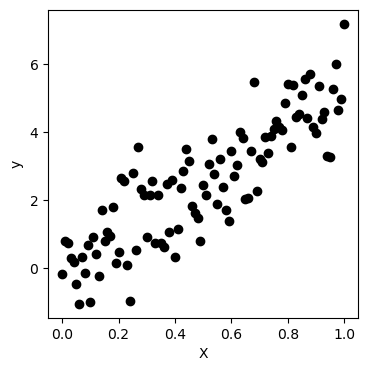

In [34]:
torch.manual_seed(2026)
X = torch.linspace(0,1,101).unsqueeze(1)

y_obs = 5*X + torch.randn_like(X)

plt.figure(figsize=(4,4))
plt.plot(X, y_obs, 'o', color='black')
plt.xlabel("X")
plt.ylabel("y");

**Demo**: In the previous section, we only used a single data point - a single observation `y_obs = 10`. Usually, we has more samples when we want to fit a model to data. After running the cell below, you'll see an interactive plot showing the model fit throughout the training of the same linear model as before. When you drag the slider, you train the model. One iteration in the training is one epoch.

In [35]:
torch.manual_seed(2025)
model = nn.Linear(1,1, bias=False)

optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)

utils.do_linear_regression_interactive(model, X, y_obs, optimizer = optimizer)

interactive(children=(IntSlider(value=0, description='Epoch:', max=30), Output()), _dom_classes=('widget-inter…

**Example**: For the model created below, create a gradient descent optimizer with learning rate `lr = 0.01`. Then, run the interactive plot and use the slider to train the model. Does the model fit the data well after 30 epochs? Compare to the demo above if you're not sure.

In [36]:
torch.manual_seed(2025)
model = nn.Linear(1,1, bias=False)

In [37]:
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

In [38]:
utils.do_linear_regression_interactive(model, X, y_obs, optimizer = optimizer)

# the model does not align with the data after 30 epochs

interactive(children=(IntSlider(value=0, description='Epoch:', max=30), Output()), _dom_classes=('widget-inter…

**Exercise**: For the model created below, create a gradient descent optimizer with learning rate `lr = 1`. Then, run the cell with the interactive plot below and use the slider to train the model. What happens to the loss throughout training? How many epochs does it take for the model to fit the data well now? Compare to the demo above if you're not sure.

In [39]:
torch.manual_seed(2025)
model = nn.Linear(1,1, bias=False)

In [40]:
optimizer = torch.optim.SGD(model.parameters(), lr = 1)

In [41]:
utils.do_linear_regression_interactive(model, X, y_obs, optimizer = optimizer)

interactive(children=(IntSlider(value=0, description='Epoch:', max=30), Output()), _dom_classes=('widget-inter…

As you may have observed in the last exercise and as the name suggests, a higher learning rate means that the model learns faster. What happens is that the parameters are updated in larger steps for each iteration. But is a higher learning rate always better?

**Exercise**: For the model created below, create a gradient descent optimizer with learning rate `lr = 3`. Then, run the cell with the interactive plot below and use the slider to train the model. What happens to the loss throughout training? Is the model able to fit the data in the end?

In [42]:
torch.manual_seed(2025)
model = nn.Linear(1,1, bias=False)

In [43]:
optimizer = torch.optim.SGD(model.parameters(), lr = 3)

In [44]:
utils.do_linear_regression_interactive(model, X, y_obs, optimizer = optimizer)

interactive(children=(IntSlider(value=0, description='Epoch:', max=30), Output()), _dom_classes=('widget-inter…

`SGD` is just one of many optimization algorithms that PyTorch provides. Let's try out some of the others. The data and model above are too simple to showcase the differences between the various algorithms, so we'll need to generate more complex data.

Run the cell below to generate data with two features.

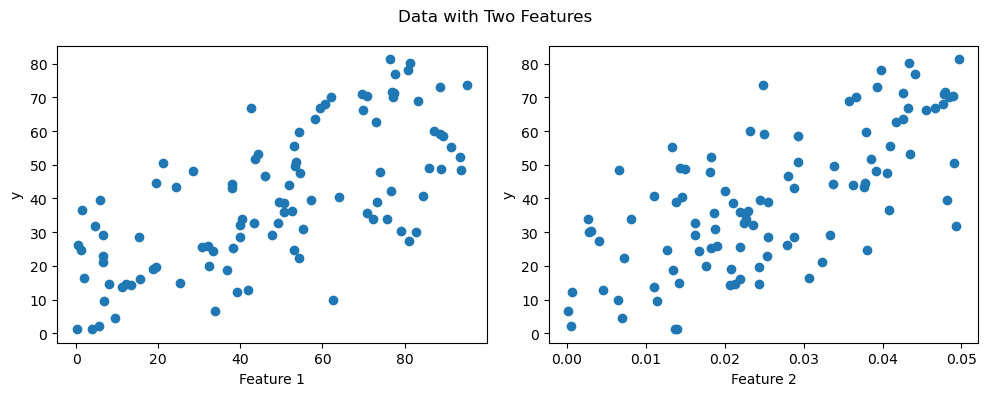

In [45]:
# generate data with multiple features different scales
torch.manual_seed(2026)

X = torch.zeros(100, 2)
X[:, 0] = 100 * torch.rand(100)
X[:, 1] = 0.05 * torch.rand(100)

y = 0.5 * X[:, 0:1] + 1000 * X[:, 1:2] + 5 * torch.randn(100, 1) - 10

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(X[:, 0], y)
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('y')

axes[1].scatter(X[:, 1], y)
axes[1].set_xlabel('Feature 2')
axes[1].set_ylabel('y')

fig.suptitle('Data with Two Features')

plt.tight_layout()

**Demo**: First, let's see how `SGD` performs on this data. Create an `SGD` optimizer with learning rate `lr = 0.01`. Then, run the cell with the interactive plot below and use the slider to train the model. Is the model able to fit the data?

In [46]:
torch.manual_seed(2025)
model = nn.Linear(2, 1)

In [47]:
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

In [48]:
utils.do_multifeature_regression_interactive(model, X, y, optimizer = optimizer)

interactive(children=(IntSlider(value=0, description='Epoch:', max=2000, step=50), Output()), _dom_classes=('w…

**Exercise**: For the model created below, create an `Adagrad` optimizer with learning rate `lr = 1`. Then, run the cell with the interactive plot below and use the slider to train the model. How does this trained model compare to the model with the SGD optimizer in the demo above?

In [49]:
torch.manual_seed(2025)
model = nn.Linear(2, 1)

In [50]:
optimizer = torch.optim.Adagrad(model.parameters(), lr = 1)

In [51]:
utils.do_multifeature_regression_interactive(model, X, y, optimizer = optimizer)

interactive(children=(IntSlider(value=0, description='Epoch:', max=2000, step=50), Output()), _dom_classes=('w…

**Exercise**: For the model created below, create an `RMSprop` optimizer with learning rate `lr = 1`. Then, run the cell with the interactive plot below and use the slider to train the model. How does this trained model compare to the model with the SGD optimizer in the demo above?

In [52]:
torch.manual_seed(2025)
model = nn.Linear(2, 1)

In [53]:
optimizer = torch.optim.RMSprop(model.parameters(), lr = 1)

In [54]:
utils.do_multifeature_regression_interactive(model, X, y, optimizer = optimizer)

interactive(children=(IntSlider(value=0, description='Epoch:', max=2000, step=50), Output()), _dom_classes=('w…

**Exercise**: For the model created below, create an `Adam` optimizer with learning rate `lr = 1`. Then, run the cell with the interactive plot below and use the slider to train the model. Is the model able to fit the data after 2000 epochs?

In [55]:
torch.manual_seed(2025)
model = nn.Linear(2, 1)

In [56]:
optimizer = torch.optim.Adam(model.parameters(), lr = 1)

In [57]:
utils.do_multifeature_regression_interactive(model, X, y, optimizer = optimizer)

interactive(children=(IntSlider(value=0, description='Epoch:', max=2000, step=50), Output()), _dom_classes=('w…

Here's a summary of the optimization algorithms we explored:

- **SGD** (`torch.optim.SGD`): Standard gradient descent with a fixed learning rate for all parameters
- **Adagrad** (`torch.optim.Adagrad`): Adapts learning rates based on historical gradients
- **RMSprop** (`torch.optim.RMSprop`): Adapts learning rates based on a **moving average** of historical gradients
- **Adam** (`torch.optim.Adam`): Adaptive learning rates combined with momentum. A popular default choice

## Section 4: Effect of Initialization

https://losslandscape.com/explorer